In [1]:
import pandas as pd
df=pd.read_csv("Cardetails.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [2]:
df=df.drop(["torque"],axis=1)
df.reset_index(inplace=True)
df=df.drop(["index"],axis=1)

In [3]:
df.shape

(8128, 12)

In [4]:
print("selling_rate")
min,max,avg,std=df.selling_price.min(),df.selling_price.max(),round(df.selling_price.mean(),2),round(df.selling_price.std(),2)
print("min :",min,"max :",max,"avg :",avg,"std :",std)

selling_rate
min : 29999 max : 10000000 avg : 638271.81 std : 806253.4


In [5]:
print(" Finding higher_selling_rate")
higher_selling_rate=round(avg + 3*std,2)
higher_selling_rate

 Finding higher_selling_rate


3057032.01

In [6]:
df=df[df.selling_price<=higher_selling_rate]
df.shape

(7899, 12)

In [7]:
df.dropna(inplace=True)

In [8]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64

In [9]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,5.0


In [10]:
def cleandata(value):
    value=value.split(" ")[0]
    value=value.strip()
    if value=="":
        value=0
    return float(value)

In [11]:
df["mileage"]=df["mileage"].apply(cleandata)
df["mileage"]=df["mileage"].astype(float)

df["engine"]=df["engine"].apply(cleandata)
df["engine"]=df["engine"].astype(float)

df["max_power"]=df["max_power"].apply(cleandata)
df["max_power"]=df["max_power"].astype(float)

In [12]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0


In [13]:
df["fuel"].unique(),df["seller_type"].unique(),df["transmission"].unique(),df["owner"].unique()

(array(['Diesel', 'Petrol', 'LPG', 'CNG'], dtype=object),
 array(['Individual', 'Dealer', 'Trustmark Dealer'], dtype=object),
 array(['Manual', 'Automatic'], dtype=object),
 array(['First Owner', 'Second Owner', 'Third Owner',
        'Fourth & Above Owner', 'Test Drive Car'], dtype=object))

In [14]:
df=df.replace([['Diesel', 'Petrol', 'LPG', 'CNG']],[1,2,3,4],inplace=True)

ValueError: Replacement lists must match in length. Expecting 1 got 4 

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

for col in ["fuel","seller_type","transmission","owner"]:
    df[col]=le.fit_transform(df[col])

In [ ]:
df["fuel"].unique(),df["seller_type"].unique(),df["transmission"].unique(),df["owner"].unique()

(array([0, 1, 2, 3], dtype=int64),
 array([1, 0, 2], dtype=int64),
 array([1, 0], dtype=int64),
 array([0, 2, 4, 1, 3], dtype=int64))

In [ ]:
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,0,1,1,0,23.40,1248.0,74.00,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,0,1,1,2,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,1,1,1,4,17.70,1497.0,78.00,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,0,1,1,0,23.00,1396.0,90.00,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,1,1,1,0,16.10,1298.0,88.20,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai i20 Magna,2013,320000,110000,1,1,1,0,18.50,1197.0,82.85,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,0,1,1,1,16.80,1493.0,110.00,5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,0,1,1,0,19.30,1248.0,73.90,5.0
8126,Tata Indigo CR4,2013,290000,25000,0,1,1,0,23.57,1396.0,70.00,5.0


In [ ]:
df["seats"]=df["seats"].astype(int)

In [ ]:
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,0,1,1,0,23.40,1248.0,74.00,5
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,0,1,1,2,21.14,1498.0,103.52,5
2,Honda City 2017-2020 EXi,2006,158000,140000,1,1,1,4,17.70,1497.0,78.00,5
3,Hyundai i20 Sportz Diesel,2010,225000,127000,0,1,1,0,23.00,1396.0,90.00,5
4,Maruti Swift VXI BSIII,2007,130000,120000,1,1,1,0,16.10,1298.0,88.20,5
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai i20 Magna,2013,320000,110000,1,1,1,0,18.50,1197.0,82.85,5
8124,Hyundai Verna CRDi SX,2007,135000,119000,0,1,1,1,16.80,1493.0,110.00,5
8125,Maruti Swift Dzire ZDi,2009,382000,120000,0,1,1,0,19.30,1248.0,73.90,5
8126,Tata Indigo CR4,2013,290000,25000,0,1,1,0,23.57,1396.0,70.00,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7678 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           7678 non-null   object 
 1   year           7678 non-null   int64  
 2   selling_price  7678 non-null   int64  
 3   km_driven      7678 non-null   int64  
 4   fuel           7678 non-null   int64  
 5   seller_type    7678 non-null   int64  
 6   transmission   7678 non-null   int64  
 7   owner          7678 non-null   int64  
 8   mileage        7678 non-null   float64
 9   engine         7678 non-null   float64
 10  max_power      7678 non-null   float64
 11  seats          7678 non-null   int32  
dtypes: float64(3), int32(1), int64(7), object(1)
memory usage: 749.8+ KB


In [ ]:
df['brand'] = df['name'].apply(lambda x: x.split()[0])


In [ ]:
cols = list(df.columns)
new_order = [cols[-1]] + cols[:-1]
df = df[new_order]

In [ ]:
df["brand"].unique()

array(['Maruti', 'Skoda', 'Honda', 'Hyundai', 'Toyota', 'Ford', 'Renault',
       'Mahindra', 'Tata', 'Chevrolet', 'Datsun', 'Jeep', 'Mercedes-Benz',
       'Mitsubishi', 'Audi', 'Volkswagen', 'BMW', 'Nissan', 'MG',
       'Jaguar', 'Daewoo', 'Volvo', 'Kia', 'Fiat', 'Force', 'Land',
       'Ambassador', 'Ashok', 'Isuzu', 'Opel'], dtype=object)

In [ ]:
# Step 1: Create a mapping (dictionary)
brand_mapping = {brand: idx for idx, brand in enumerate(df['brand'].unique())}

# Step 2: Apply the mapping to the 'brand' column
df['brand'] = df['brand'].map(brand_mapping)

In [ ]:
df["brand"]=df["brand"].astype(int)

In [ ]:
df["brand"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])

In [ ]:
df=df.drop(["name"],axis=1)

In [ ]:
df

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,0,2014,450000,145500,0,1,1,0,23.40,1248.0,74.00,5
1,1,2014,370000,120000,0,1,1,2,21.14,1498.0,103.52,5
2,2,2006,158000,140000,1,1,1,4,17.70,1497.0,78.00,5
3,3,2010,225000,127000,0,1,1,0,23.00,1396.0,90.00,5
4,0,2007,130000,120000,1,1,1,0,16.10,1298.0,88.20,5
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,3,2013,320000,110000,1,1,1,0,18.50,1197.0,82.85,5
8124,3,2007,135000,119000,0,1,1,1,16.80,1493.0,110.00,5
8125,0,2009,382000,120000,0,1,1,0,19.30,1248.0,73.90,5
8126,8,2013,290000,25000,0,1,1,0,23.57,1396.0,70.00,5


In [ ]:
min1,max1,avg1,std1=df.mileage.min(),df.mileage.max(),round(df.mileage.mean()),round(df.mileage.std())

In [ ]:
min1,max1,avg1,std1

(0.0, 33.44, 19, 4)

In [ ]:
mileage_high=avg1+std1*3

In [ ]:
df=df[df.mileage<=mileage_high]

In [ ]:
min2,max2,avg2,std2=df.km_driven.min(),df.km_driven.max(),round(df.km_driven.mean()),round(df.km_driven.std())

In [ ]:
min2,max2,avg2,std2

(1, 2360457, 70589, 57011)

In [ ]:
km_driven_high=avg2+std2*3

In [ ]:
df=df[df.km_driven<=km_driven_high]

In [ ]:
min3,max3,avg3,std3=df.engine.min(),df.engine.max(),round(df.engine.mean()),round(df.engine.std())

In [ ]:
min3,max3,avg3,std3

(624.0, 3498.0, 1430, 483)

In [ ]:
engine_high=avg2+std2*3

In [ ]:
df=df[df.engine<=engine_high]

In [ ]:
min4,max4,avg4,std4=df.max_power.min(),df.max_power.max(),round(df.max_power.mean()),round(df.max_power.std())

In [ ]:
min4,max4,avg4,std4

(0.0, 272.0, 88, 31)

In [ ]:
max_power_high=avg2+std2*3

In [ ]:
df=df[df.max_power<=max_power_high]

In [ ]:
min5,max5,avg5,std5=df.selling_price.min(),df.selling_price.max(),round(df.selling_price.mean(),2),round(df.selling_price.std(),2)
h=avg5+std5*3
min5,max5,avg5,std5,h
df=df[df.selling_price<=h]

In [ ]:
print(df.columns)


Index(['brand', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats'],
      dtype='object')


In [ ]:
x=df[["brand","year","km_driven","fuel","seller_type","transmission","owner","mileage","engine","max_power","seats"]]
y=df["selling_price"]

In [ ]:
print(x.shape)
print(y.shape)

(7399, 11)
(7399,)


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=7)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(x_train, y_train)

RandomForestRegressor()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))  # closer to 1 = better

MAE: 56757.07740851637
MSE: 7301787826.204325
R² Score: 0.9189654742166689


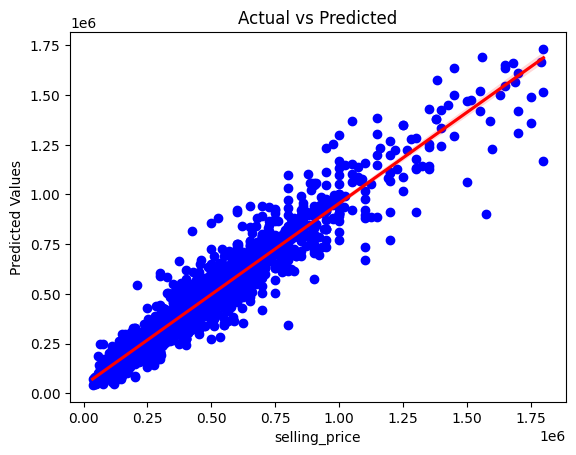

In [ ]:
# Scatter plot
import seaborn as sns
import matplotlib.pyplot as plt  # Correct import

plt.scatter(y_test, y_pred, color='blue')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')

# Add regression line
sns.regplot(x=y_test, y=y_pred, line_kws={"color": "red"}, scatter=False)

plt.show()


In [ ]:
from joblib import  dump
dump(model,"model.pk1")

['model.pk1']